# **Elevation Based Link Budget Calculation**


**Based On:**
Gongora-Torres, J. M., Vargas-Rosales, C., Aragón-Zavala, A., & Villalpando-Hernandez, R. (2022). Link Budget Analysis for LEO Satellites Based on the Statistics of the Elevation Angle. IEEE Access, 10, 14518–14528. https://doi.org/10.1109/ACCESS.2022.3147829

The script replicates the core orbital mechanics used to trace the LEO satellite's position relative to the Earth Station (ES) over time, calculates the elevation angle ($\theta$) at 5-second intervals, filters the visible contacts, and fits the resulting data to a Gamma distribution as detailed in Section III-A.

In [6]:
# Library Export

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

### Initial Parameter Definitions

In [7]:
# Simulation parameters extracted from Table 2 of the paper
SIMULATION_DAYS = 500       # Reduced from 640 days for fast local execution
TIME_STEP_S = 5.0           # Time step of 5 seconds
LAT_ES_DEG = 28.230880        # ES location latitude (N)
LON_ES_DEG = -81.820348   # ES location longitude (W)
ECCENTRICITY = 0.0          # Orbit eccentricity (e)
INCLINATION_DEG = 40.0      # Orbit inclination (i) in degrees

# --- CONSTELLATION PARAMETERS ---
ALTITUDE_KM = 980.0         # Satellite altitude in km (Replaces A_KM)
NUM_PLANES = 5              # Number of orbital rings around the Earth
SATS_PER_PLANE = 5         # Number of satellites evenly spaced in each ring
# (Total constellation size = 60 satellites)

# Observation constraints
MIN_ELEVATION_DEG = 5.0     # Minimum elevation angle (matches CDF plots)

# Constants for Earth
R_EARTH_KM = 6371.0         # Earth radius in km
MU_EARTH = 398600.4418      # Earth gravitational parameter (km^3/s^2)
OMEGA_EARTH = 7.2921159e-5  # Earth rotation rate (rad/s)

## Orbital Propagation & Elevation Calculation (Contact Duration Calculation)

This calculation implements the theoretical fundamentals outlined in Section II-A and the simulation methodology of Section III of the reference study, specifically focusing on the continuous derivation of the elevation angle ($\theta$). Due to the rapid mobility of Low Earth Orbit (LEO) satellites, the elevation angle and the corresponding path length are highly time-varying, making traditional static link budget models inadequate. To accurately characterize this, the algorithm propagates the satellite's orbit over time using Keplerian mechanics for a circular orbit, transforming coordinates from the Earth-Centered Inertial (ECI) frame to the Earth-Centered Earth-Fixed (ECEF) frame to account for Earth's rotation. Conceptually, readers should understand this as generating the raw, physical spatial data necessary to evaluate the link's geometric visibility; it identifies exactly when and at what angle the satellite appears above the local horizon line relative to a static Earth Station (ES). The mathematical foundation for extracting the elevation angle based on the instantaneous geometric relations is governed by the equation:


$$\theta = \arctan \left( \frac{\cos(A)\cos(\phi_{ES}) - (r_{E,O}/r_{S,O})}{\sqrt{1 - \cos^2(A)\cos^2(\phi_{ES})}} \right)$$

where $r_{E,O}$ and $r_{S,O}$ are the distances from the Earth's center to the ES and satellite respectively, $\phi_{ES}$ is the ES latitude, and $A$ is the longitude difference between the ES and the subsatellite point.


In [8]:
def run_simulation():
    total_sats = NUM_PLANES * SATS_PER_PLANE
    print(f"Initializing {total_sats}-satellite constellation simulation...")
    
    # 1. Base setup
    inc = np.radians(INCLINATION_DEG)
    lat_es = np.radians(LAT_ES_DEG)
    lon_es = np.radians(LON_ES_DEG)
    a_km = R_EARTH_KM + ALTITUDE_KM  # Calculate Semi-major axis from Altitude
    
    # Time array and Earth rotation
    t = np.arange(0, SIMULATION_DAYS * 24 * 3600, TIME_STEP_S)
    n = np.sqrt(MU_EARTH / a_km**3)
    
    theta_gst = OMEGA_EARTH * t
    cos_theta = np.cos(theta_gst)
    sin_theta = np.sin(theta_gst)
    
    # Earth Station (ES) ECEF Position & Up Vector
    x_es = R_EARTH_KM * np.cos(lat_es) * np.cos(lon_es)
    y_es = R_EARTH_KM * np.cos(lat_es) * np.sin(lon_es)
    z_es = R_EARTH_KM * np.sin(lat_es)
    
    up_x = np.cos(lat_es) * np.cos(lon_es)
    up_y = np.cos(lat_es) * np.sin(lon_es)
    up_z = np.sin(lat_es)
    
    # Array to track the MAXIMUM elevation angle across all satellites at any given second
    max_elevation_over_time = np.full(len(t), -90.0) 
    
    # 2. Iterate through the entire constellation (Planes and Satellites)
    for p in range(NUM_PLANES):
        # Calculate Right Ascension of the Ascending Node (RAAN) to space out the rings
        raan = p * (2 * np.pi / NUM_PLANES)
        
        for s in range(SATS_PER_PLANE):
            # Calculate Initial True Anomaly to space out satellites within the ring
            v_init = s * (2 * np.pi / SATS_PER_PLANE)
            
            # True anomaly over time for this specific satellite
            v = v_init + n * t
            
            # Orbital plane coordinates
            x_orb = a_km * np.cos(v)
            y_orb = a_km * np.sin(v)
            
            # 3D Rotation for Inclination AND RAAN (ECI coordinates)
            x_eci = x_orb * np.cos(raan) - y_orb * np.cos(inc) * np.sin(raan)
            y_eci = x_orb * np.sin(raan) + y_orb * np.cos(inc) * np.cos(raan)
            z_eci = y_orb * np.sin(inc)
            
            # Convert to ECEF (Earth fixed)
            x_ecef = x_eci * cos_theta + y_eci * sin_theta
            y_ecef = -x_eci * sin_theta + y_eci * cos_theta
            z_ecef = z_eci
            
            # Vector from ES to Satellite
            dx = x_ecef - x_es
            dy = y_ecef - y_es
            dz = z_ecef - z_es
            dist = np.sqrt(dx**2 + dy**2 + dz**2)
            
            # Calculate Elevation Angle
            dot_prod = dx*up_x + dy*up_y + dz*up_z
            sin_el = dot_prod / dist
            el_deg = np.degrees(np.arcsin(sin_el))
            
            # 3. Handover Logic: Only keep the satellite with the highest elevation
            max_elevation_over_time = np.maximum(max_elevation_over_time, el_deg)
            
    # Filter for times when AT LEAST ONE satellite is visible above the minimum threshold
    visible_elevations = max_elevation_over_time[max_elevation_over_time >= MIN_ELEVATION_DEG]
    
    print(f"Simulation complete. Constellation active for {len(visible_elevations)} data points.")
    return visible_elevations

### Statistical Analysis & Gamma Fitting

Aligning with Section III-A of the paper, this component of the code treats the continuous stream of deterministic elevation angles as a stochastic process, characterizing $\theta$ as a random variable ($\Theta$). Standard link budgets typically evaluate only the extreme boundary conditions (best and worst cases), which fail to capture the true operational behavior and frequency of specific link conditions over time. To provide a comprehensive probabilistic framework, the empirically recorded elevation angles are aggregated and fitted to a continuous Gamma distribution. For the reader, this step transitions the analysis from a purely geometric orbital simulation into a predictive statistical domain, enabling the calculation of expected system performance over a long-term deployment. The probability density function (PDF) and cumulative distribution function (CDF) of the elevation angle are defined mathematically by the Gamma distribution parameters (shape $a$ and scale $b$) as:


$$f_{\Theta} = \frac{1}{b^a \Gamma(a)} \theta^{a-1} \exp(-\theta/b)$$


and


$$F_{\Theta} = \frac{1}{\Gamma(a)} \gamma(a, \theta/b)$$

where $\Gamma(\cdot)$ is the gamma function and $\gamma(\cdot)$ is the lower incomplete gamma function.


In [9]:
def plot_gamma_fit(data):
    print("Fitting data to Gamma distribution...")
    
    # Fit the visible elevation data to a Gamma distribution using MLE
    # scipy's gamma fit returns: (shape, loc, scale)
    shape, loc, scale = gamma.fit(data, floc=0)
    
    print("\n--- Gamma Distribution Parameters ---")
    print(f"Shape parameter (a) : {shape:.4f}")
    print(f"Scale parameter (b) : {scale:.4f}")
    
    # Setup the plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # X-axis range for continuous plotting
    x = np.linspace(MIN_ELEVATION_DEG, 90, 1000)
    pdf_fitted = gamma.pdf(x, shape, loc=loc, scale=scale)
    cdf_fitted = gamma.cdf(x, shape, loc=loc, scale=scale)
    
    # Plot 1: Probability Density Function (PDF)
    axes[0].hist(data, bins=90, density=True, alpha=0.5, label='Empirical PDF (Data)')
    axes[0].plot(x, pdf_fitted, 'r-', lw=2, label='Gamma Fit')
    axes[0].set_title('PDF of Elevation Angle (θ)')
    axes[0].set_xlabel('θ (degrees)')
    axes[0].set_ylabel('f_θ')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    # Plot 2: Cumulative Distribution Function (CDF)
    # Calculate empirical CDF
    data_sorted = np.sort(data)
    p = 1. * np.arange(len(data)) / (len(data) - 1)
    
    axes[1].plot(data_sorted, p, 'b-', label='Empirical CDF')
    axes[1].plot(x, cdf_fitted, 'r--', lw=2, label='Gamma Fit')
    axes[1].set_title('CDF of Elevation Angle (θ)')
    axes[1].set_xlabel('θ (degrees)')
    axes[1].set_ylabel('F_θ')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

Initializing 25-satellite constellation simulation...
Simulation complete. Constellation active for 7868234 data points.
Fitting data to Gamma distribution...

--- Gamma Distribution Parameters ---
Shape parameter (a) : 2.5945
Scale parameter (b) : 10.6972


C:\Users\ADVAN\AppData\Local\Temp\ipykernel_20716\3505186464.py:42: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\ADVAN\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


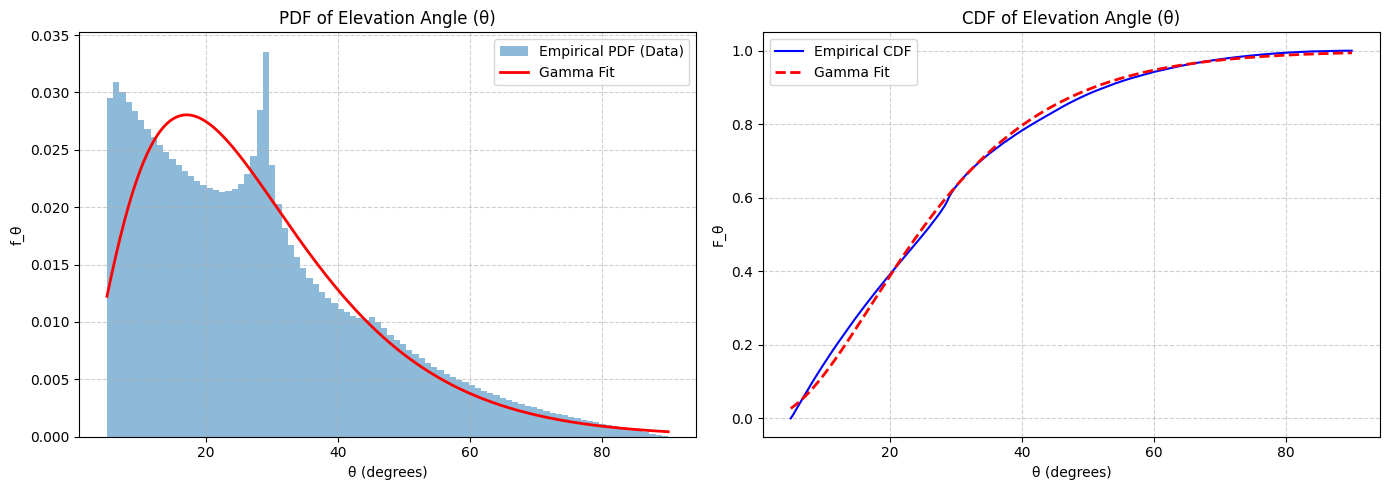

In [10]:
if __name__ == "__main__":
    elevation_data = run_simulation()
    if len(elevation_data) > 0:
        plot_gamma_fit(elevation_data)
    else:
        print("No visible passes detected. Check your parameters.")

### Mean Contact Duration

This code block replicates the temporal visibility analysis discussed in the Methodology section and visualized in Figure 2 of the source document. By defining a minimum usability threshold (e.g., $\theta \ge 10^\circ$), the algorithm isolates discrete satellite passes and calculates the exact contact duration in seconds for each visible event. These individual durations are subsequently grouped and averaged over 24-hour periods to yield the daily mean contact duration. Readers should view this analysis as a practical characterization of network availability, illustrating how the highly dynamic LEO orbital mechanics—alongside natural orbital perturbations—cause observable daily oscillations in the overall contact time. While the paper does not rely on a standalone analytical equation for this metric, the fundamental operation defines the duration for the $i$-th pass as $\Delta t_i = t_{end,i} - t_{start,i}$ subject to the condition $\theta(t) \ge \theta_{min}$, establishing the baseline for understanding the system's temporal coverage footprint.


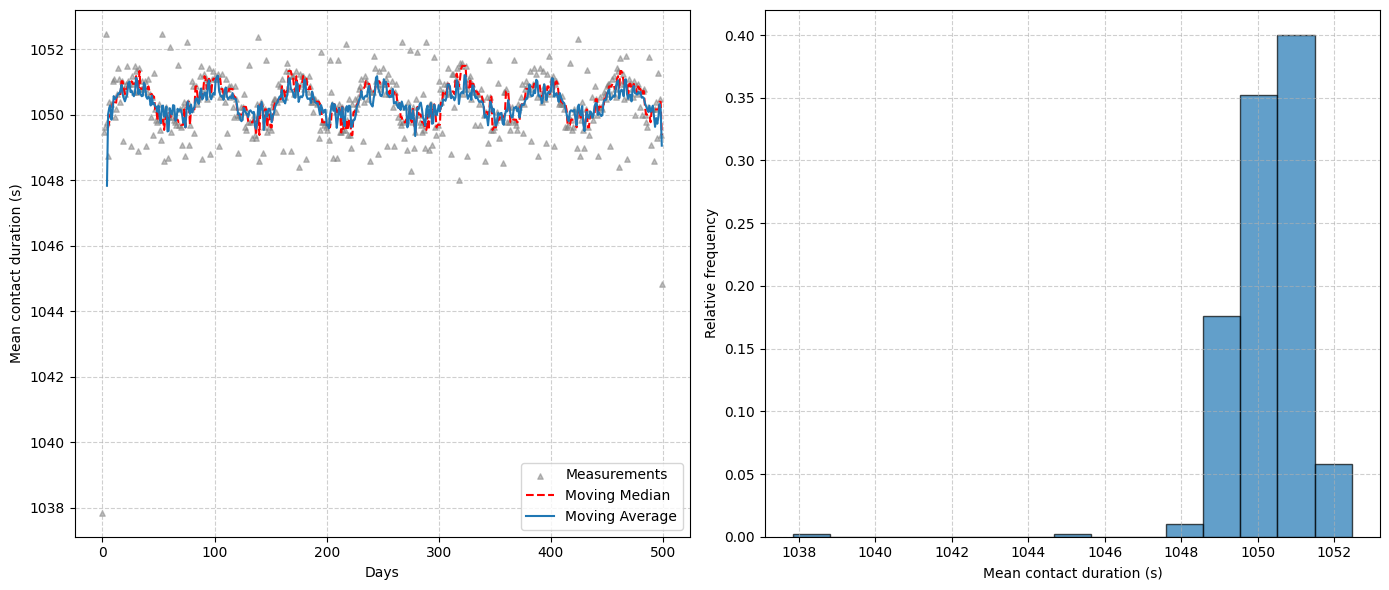

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Recalculate orbital mechanics for the CONSTELLATION to access full time (t) and elevation (el_deg)
total_seconds = SIMULATION_DAYS * 24 * 3600
t = np.arange(0, total_seconds, TIME_STEP_S)

a_km = R_EARTH_KM + ALTITUDE_KM  # Using the new Altitude parameter
n = np.sqrt(MU_EARTH / a_km**3)
inc = np.radians(INCLINATION_DEG)
lat_es = np.radians(LAT_ES_DEG)
lon_es = np.radians(LON_ES_DEG)

theta_gst = OMEGA_EARTH * t
cos_theta = np.cos(theta_gst)
sin_theta = np.sin(theta_gst)

x_es = R_EARTH_KM * np.cos(lat_es) * np.cos(lon_es)
y_es = R_EARTH_KM * np.cos(lat_es) * np.sin(lon_es)
z_es = R_EARTH_KM * np.sin(lat_es)

up_x = np.cos(lat_es) * np.cos(lon_es)
up_y = np.cos(lat_es) * np.sin(lon_es)
up_z = np.sin(lat_es)

# Initialize the array to track the MAXIMUM elevation across the constellation
el_deg = np.full(len(t), -90.0)

for p in range(NUM_PLANES):
    raan = p * (2 * np.pi / NUM_PLANES)
    for s in range(SATS_PER_PLANE):
        v_init = s * (2 * np.pi / SATS_PER_PLANE)
        v = v_init + n * t
        
        x_orb = a_km * np.cos(v)
        y_orb = a_km * np.sin(v)
        
        # 3D Rotation for Inclination AND RAAN (ECI coordinates)
        x_eci = x_orb * np.cos(raan) - y_orb * np.cos(inc) * np.sin(raan)
        y_eci = x_orb * np.sin(raan) + y_orb * np.cos(inc) * np.cos(raan)
        z_eci = y_orb * np.sin(inc)
        
        x_ecef = x_eci * cos_theta + y_eci * sin_theta
        y_ecef = -x_eci * sin_theta + y_eci * cos_theta
        z_ecef = z_eci
        
        dx = x_ecef - x_es
        dy = y_ecef - y_es
        dz = z_ecef - z_es
        dist = np.sqrt(dx**2 + dy**2 + dz**2)
        
        sin_el_temp = (dx*up_x + dy*up_y + dz*up_z) / dist
        el_deg_temp = np.degrees(np.arcsin(sin_el_temp))
        
        # Handover logic: Always take the highest satellite
        el_deg = np.maximum(el_deg, el_deg_temp)


# 2. Extract Contact Durations (Constellation Network Availability)
CONTACT_THRESHOLD_DEG = 10.0
is_visible = el_deg >= CONTACT_THRESHOLD_DEG

# Find where the constellation goes above (1) and below (-1) the threshold
visibility_changes = np.diff(is_visible.astype(int))
starts = np.where(visibility_changes == 1)[0]
ends = np.where(visibility_changes == -1)[0]

# Handle edge cases (if simulation starts/ends exactly during a contact)
if is_visible[0]:
    starts = np.insert(starts, 0, 0)
if is_visible[-1]:
    ends = np.append(ends, len(is_visible) - 1)

contact_durations = []
contact_days = []

# Calculate the duration of each continuous network availability window
for s, e in zip(starts, ends):
    duration = t[e] - t[s]
    day = t[s] / (24 * 3600)
    contact_durations.append(duration)
    contact_days.append(day)

contact_durations = np.array(contact_durations)
contact_days_int = np.floor(np.array(contact_days)).astype(int)

# 3. Calculate Daily Mean Contact Duration
unique_days = np.unique(contact_days_int)
daily_mean_durations = np.array([np.mean(contact_durations[contact_days_int == day]) for day in unique_days])

# Calculate moving average and moving median 
window_size = 5
if len(daily_mean_durations) >= window_size:
    moving_avg = np.convolve(daily_mean_durations, np.ones(window_size)/window_size, mode='valid')
    moving_med = [np.median(daily_mean_durations[i:i+window_size]) for i in range(len(daily_mean_durations)-window_size+1)]
    valid_days = unique_days[window_size-1:]
else:
    moving_avg = daily_mean_durations
    moving_med = daily_mean_durations
    valid_days = unique_days

# 4. Plotting Figures 2(a) and 2(b)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(unique_days, daily_mean_durations, color='gray', alpha=0.5, s=15, label='Measurements', marker='^')
if len(valid_days) > 0:
    axes[0].plot(valid_days, moving_med, color='red', linestyle='--', linewidth=1.5, label='Moving Median')
    axes[0].plot(valid_days, moving_avg, color='tab:blue', linewidth=1.5, label='Moving Average')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Mean contact duration (s)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

if len(daily_mean_durations) > 0:
    weights = np.ones_like(daily_mean_durations) / len(daily_mean_durations)
    axes[1].hist(daily_mean_durations, bins=15, weights=weights, edgecolor='black', color='tab:blue', alpha=0.7)
    axes[1].set_xlabel('Mean contact duration (s)')
    axes[1].set_ylabel('Relative frequency')
    axes[1].grid(True, linestyle='--', alpha=0.6)
else:
    axes[1].text(0.5, 0.5, 'No Dropouts (100% Uptime)', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

## Link Budget Analysis

This final section executes the primary contribution of the paper, located in Sections III-B and III-C: the calculation of the statistical link budget. Unlike traditional satellite communications link budgets that assume a static distance, this methodology integrates the atmospheric and free-space path losses as a continuous, symmetric function of the variable elevation angle, approximated via a polynomial regression $A_T(\theta)$. By coupling this deterministic attenuation model with the previously derived Gamma distribution of the elevation angle, the code computes the probabilistic characteristics of the received power, including its expected value, standard deviation, and quartiles. A reader should interpret this as a highly realistic evaluation of link quality; it provides an expectation of the signal strength a receiver will experience *most of the time*, rather than relying on isolated boundary conditions. The total attenuation as a function of the elevation angle is approximated by the standardized polynomial:


$$A_T(\theta) = \sum_{k=0}^K a_k \left( \frac{\theta - \mu_\theta}{\sigma_\theta} \right)^{K-k}$$


while the expected received power outside of outage conditions is fundamentally derived from the standard link budget equation as:


$$E[P_R|\theta \ge \theta_{min}] = EIRP + G_R - A_T(E[\theta|\theta \ge \theta_{min}])$$

where $EIRP$ is the Effective Isotropic Radiated Power and $G_R$ is the receiver antenna gain.

=== LINK BUDGET ANALYSIS (p_e = 1.00%) ===
Min Elevation Angle: 5.0°
  Worst-Case P_R (Min P_R) : -106.40 dBW
  Best-Case P_R (Max P_R)  : -81.49 dBW
  Expected P_R (Mean)      : -96.95 dBW
  Median P_R               : -95.98 dBW
  P_R Quartiles (Q1, Q3)   : (-97.61, -95.14) dBW
  Link Margin (Expected)   : 8.05 dB

=== LINK BUDGET ANALYSIS (p_e = 5.00%) ===
Min Elevation Angle: 9.0°
  Worst-Case P_R (Min P_R) : -104.61 dBW
  Best-Case P_R (Max P_R)  : -99.73 dBW
  Expected P_R (Mean)      : -98.45 dBW
  Median P_R               : -97.64 dBW
  P_R Quartiles (Q1, Q3)   : (-99.06, -96.61) dBW
  Link Margin (Expected)   : 6.55 dB



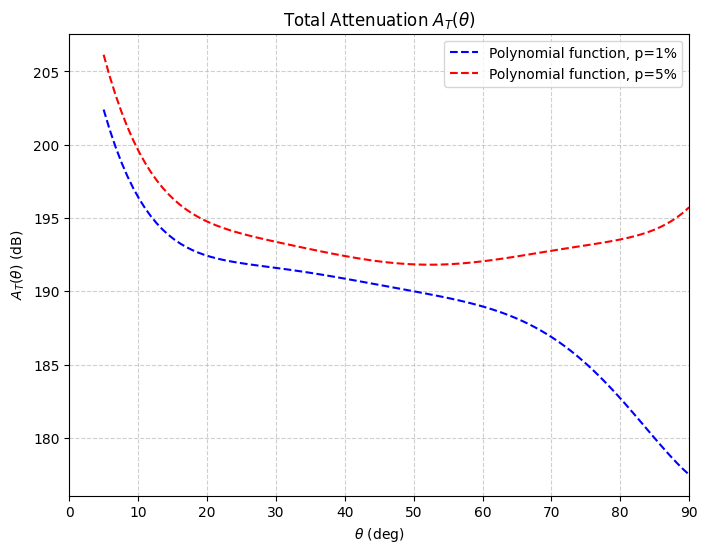

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# --- LINK BUDGET PARAMETERS (From Table 5) ---
EIRP = 56.0         # Transmitter EIRP in dBW
G_R = 40.0          # Receiver antenna gain in dBi
P_REQ = -105.0      # Required received power in dBW
THETA_MIN_1 = 5.0   # min elevation for 1% exceedance
THETA_MIN_5 = 9.0   # min elevation for 5% exceedance

# --- ATTENUATION POLYNOMIAL COEFFICIENTS (From Table 4) ---
# a_k coefficients for pe = 1.00% and pe = 5.00%
a_coef_1 = [0.463, -2.153, 2.578, -0.636, -0.700, -1.616, 191.449]
a_coef_5 = [0.430, -2.091, 2.891, -0.331, 0.277, -2.427, 193.140]

# Normalization factors for the polynomial
mu_theta = 32.329
sigma_theta = 24.203

def calculate_At(theta, coefficients):
    """Calculates Total Attenuation A_T(theta) using Eq. 13"""
    normalized_theta = (theta - mu_theta) / sigma_theta
    A_t = 0
    K = len(coefficients) - 1
    for k, a_k in enumerate(coefficients):
        A_t += a_k * (normalized_theta ** (K - k))
    return A_t

# --- STATISTICAL ANALYSIS OF RECEIVED POWER ---
# We use the elevation_data array generated from your earlier `run_simulation()`

def analyze_link_budget(theta_data, theta_min, coefs, pe_label):
    # Filter theta for the valid contact window (theta >= theta_min)
    valid_theta = theta_data[theta_data >= theta_min]
    
    if len(valid_theta) == 0:
        return
        
    # Fit the Gamma distribution for the valid angles
    shape, loc, scale = gamma.fit(valid_theta, floc=0)
    
    # Calculate statistics of theta
    mean_theta = np.mean(valid_theta)
    std_theta = np.std(valid_theta)
    
    # Generate distribution points to find expected values
    theta_samples = gamma.rvs(shape, loc=loc, scale=scale, size=100000)
    
    # 1. Total Attenuation Statistics (A_T)
    # Calculate A_T for all samples
    At_samples = calculate_At(theta_samples, coefs)
    
    expected_At = np.mean(At_samples)
    min_At = calculate_At(90.0, coefs) # Best case is always at zenith (90 deg)
    max_At = calculate_At(theta_min, coefs) # Worst case is at horizon (theta_min)
    
    # 2. Received Power Statistics (P_R)
    # P_R = EIRP + G_R - A_T(theta)
    Pr_samples = EIRP + G_R - At_samples
    
    expected_Pr = np.mean(Pr_samples)
    min_Pr = EIRP + G_R - max_At # Corresponds to max attenuation
    max_Pr = EIRP + G_R - min_At # Corresponds to min attenuation
    
    q1_Pr = np.percentile(Pr_samples, 25)
    med_Pr = np.median(Pr_samples)
    q3_Pr = np.percentile(Pr_samples, 75)
    
    # Convert std back from linear power limits (as per Eq 19 logic approximations)
    pr_linear_mean = 10**(expected_Pr/10)
    pr_linear_std = np.std(10**(Pr_samples/10))
    
    print(f"=== LINK BUDGET ANALYSIS (p_e = {pe_label}) ===")
    print(f"Min Elevation Angle: {theta_min}°")
    print(f"  Worst-Case P_R (Min P_R) : {min_Pr:.2f} dBW")
    print(f"  Best-Case P_R (Max P_R)  : {max_Pr:.2f} dBW")
    print(f"  Expected P_R (Mean)      : {expected_Pr:.2f} dBW")
    print(f"  Median P_R               : {med_Pr:.2f} dBW")
    print(f"  P_R Quartiles (Q1, Q3)   : ({q1_Pr:.2f}, {q3_Pr:.2f}) dBW")
    print(f"  Link Margin (Expected)   : {expected_Pr - P_REQ:.2f} dB\n")

# Run the analysis for both 1% and 5% exceedance probabilities

analyze_link_budget(elevation_data, THETA_MIN_1, a_coef_1, "1.00%")
analyze_link_budget(elevation_data, THETA_MIN_5, a_coef_5, "5.00%")

# --- VISUALIZATION: Plotting Figure 9 ---
theta_plot = np.linspace(THETA_MIN_1, 90, 100)
At_1_plot = calculate_At(theta_plot, a_coef_1)
At_5_plot = calculate_At(theta_plot, a_coef_5)

plt.figure(figsize=(8, 6))
plt.plot(theta_plot, At_1_plot, 'b--', label='Polynomial function, p=1%')
plt.plot(theta_plot, At_5_plot, 'r--', label='Polynomial function, p=5%')
plt.title('Total Attenuation $A_T(\\theta)$')
plt.xlabel('$\\theta$ (deg)')
plt.ylabel('$A_T(\\theta)$ (dB)')
plt.xlim(0, 90)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### Total Attenuation $A_T(\theta)$ Weighted by Occurrence Frequency

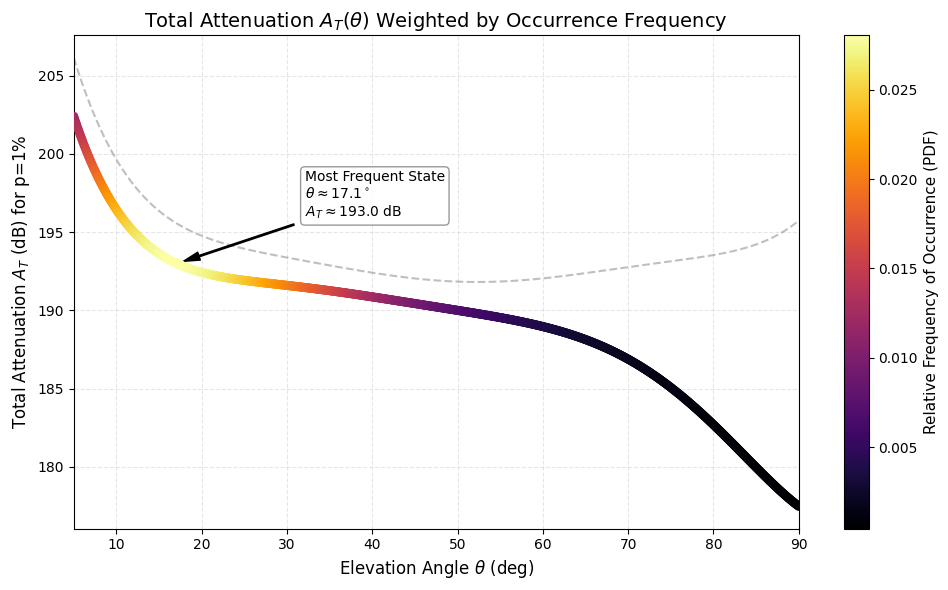

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# 1. Recalculate the Gamma distribution parameters based on valid contacts
valid_theta = elevation_data[elevation_data >= THETA_MIN_1]
shape, loc, scale = gamma.fit(valid_theta, floc=0)

# 2. Generate high-resolution arrays for the smooth plot
theta_plot = np.linspace(THETA_MIN_1, 90, 1000)
At_1_plot = calculate_At(theta_plot, a_coef_1)
At_5_plot = calculate_At(theta_plot, a_coef_5)

# 3. Calculate the Probability Density (Frequency of occurrence)
# This will act as our "Heatmap" metric
pdf_values = gamma.pdf(theta_plot, shape, loc=loc, scale=scale)

# 4. Plotting the Heatmap visualization
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the 5% exceedance as a standard background reference line
ax1.plot(theta_plot, At_5_plot, color='gray', linestyle='--', alpha=0.5, label='$A_T$ (p=5%) Reference')

# Plot the 1% exceedance curve using a scatter plot mapped to a color gradient (Heatmap)
# 'inferno' or 'hot' colormaps are great for highlighting density
scatter = ax1.scatter(theta_plot, At_1_plot, c=pdf_values, cmap='inferno', s=30, zorder=5)

# Formatting the plot
ax1.set_title('Total Attenuation $A_T(\\theta)$ Weighted by Occurrence Frequency', fontsize=14)
ax1.set_xlabel('Elevation Angle $\\theta$ (deg)', fontsize=12)
ax1.set_ylabel('Total Attenuation $A_T$ (dB) for p=1%', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.set_xlim(THETA_MIN_1, 90)

# Add the colorbar representing the frequency axis (FIXED HERE)
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Relative Frequency of Occurrence (PDF)', fontsize=11)

# Add a marker for the highest probability "Hotspot"
max_prob_index = np.argmax(pdf_values)
hotspot_theta = theta_plot[max_prob_index]
hotspot_At = At_1_plot[max_prob_index]

ax1.annotate(f'Most Frequent State\n$\\theta \\approx {hotspot_theta:.1f}^\\circ$\n$A_T \\approx {hotspot_At:.1f}$ dB', 
             xy=(hotspot_theta, hotspot_At), 
             xytext=(hotspot_theta + 15, hotspot_At + 3),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()